Équation : y = (0.3109)x² + (6.3174)x + 5.1470


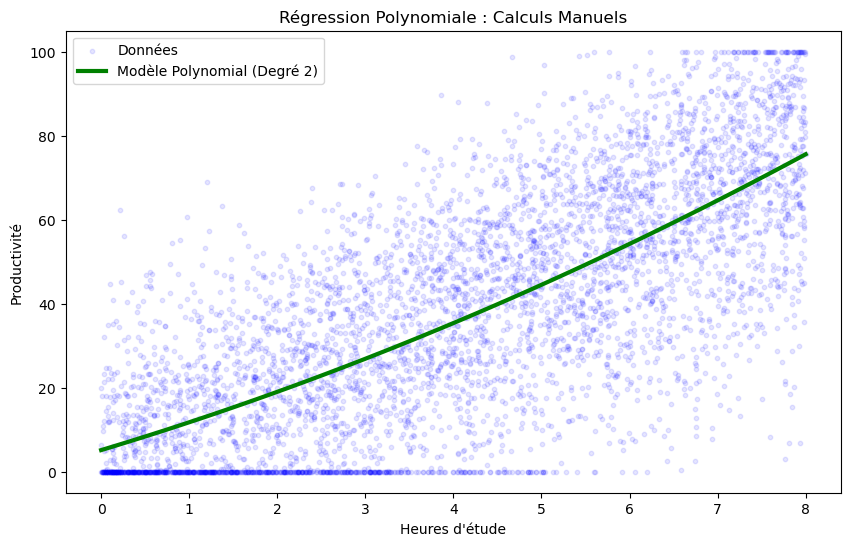

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Données
df = pd.read_csv('social_media_productivity_6000.csv').dropna()
x_raw = df['study_hours'].values
y = df['productivity_score'].values

# 2. CONSTRUCTION DE LA MATRICE X (Manuellement)
# On crée les colonnes : [1, x, x^2]
col_1 = np.ones(x_raw.shape[0])
col_x = x_raw
col_x2 = x_raw**2

# On empile les colonnes pour créer la matrice
X = np.column_stack((col_1, col_x, col_x2)) # colum_stack fonctionne comme la fonction PolynomialFeatures

# 3. CALCUL DES COEFFICIENTS (Équation Normale)
# B = (X.T * X)^-1 * X.T * y
B = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

intercept = B[0]  # b
coeff_x = B[1]    # a1
coeff_x2 = B[2]   # a2

print(f"Équation : y = ({coeff_x2:.4f})x² + ({coeff_x:.4f})x + {intercept:.4f}")

# 4. VISUALISATION DE LA COURBE
plt.figure(figsize=(10, 6))
plt.scatter(x_raw, y, color='blue', alpha=0.1, s=10, label='Données')

# Pour tracer une courbe lisse, on crée 100 points entre le min et le max
x_curve = np.linspace(x_raw.min(), x_raw.max(), 100)
# On applique l'équation calculée : y = a2*x^2 + a1*x + b
y_curve = intercept + (coeff_x * x_curve) + (coeff_x2 * x_curve**2)

plt.plot(x_curve, y_curve, color='green', linewidth=3, label='Modèle Polynomial (Degré 2)')
plt.xlabel('Heures d\'étude')
plt.ylabel('Productivité')
plt.legend()
plt.title('Régression Polynomiale : Calculs Manuels')
plt.show()